In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
np.random.seed(42)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ══════════════════════════════════════════════════════
# RAW DATA GENERATION
# 7 days of 1-minute pressure readings with injected faults
# ══════════════════════════════════════════════════════

# 7 days at 1 reading per minute
timestamps = pd.date_range(start="2024-01-15 00:00", periods=7*24*60, freq="min")
n = len(timestamps)

# Baseline pressure - normal operation around 250 bar
pressure = np.random.normal(250, 3, n)

# FAULT 1 - DRIFT: slow sensor drift from day 4 (hydrogen membrane contamination)
drift_start = 4 * 24 * 60
drift = np.zeros(n)
drift[drift_start:] = np.linspace(0, 25, n - drift_start)
pressure = pressure + drift

# FAULT 2 - SPIKES: 5 sudden single point outliers
spike_indices = np.random.choice(n, 5)
pressure[spike_indices] = pressure[spike_indices] + np.random.uniform(40, 80, 5)

# FAULT 3 - CLIPPING: PLC range error on day 2 for 2 hours
clip_start = 2 * 24 * 60
clip_end = clip_start + 120
pressure[clip_start:clip_end] = 280

# FAULT 4 - MISSING VALUES: exception reporting and comms dropouts
missing_indices = np.random.choice(n, 500, replace=False)
pressure[missing_indices] = np.nan

# Build raw DataFrame
ts_df = pd.DataFrame({
    "timestamp": timestamps,
    "pressure": pressure
})

print(f"Dataset generated ✓")
print(f"Total readings:     {n:,}")
print(f"Missing values:     {ts_df['pressure'].isna().sum()}")
print(f"Values at 280 bar:  {(ts_df['pressure'] == 280.0).sum()}")
print(f"Max pressure:       {ts_df['pressure'].max():.1f} bar")
print(f"Date range:         {ts_df['timestamp'].iloc[0]} to {ts_df['timestamp'].iloc[-1]}")

Dataset generated ✓
Total readings:     10,080
Missing values:     500
Values at 280 bar:  112
Max pressure:       344.1 bar
Date range:         2024-01-15 00:00:00 to 2024-01-21 23:59:00


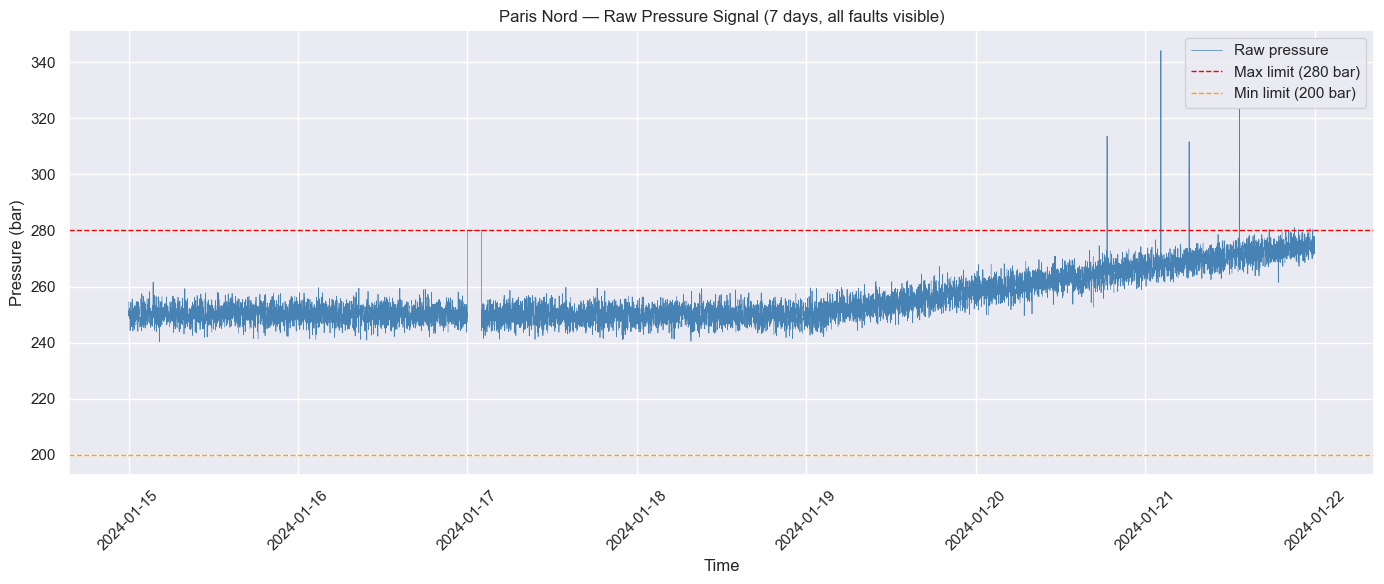

In [3]:
# ══════════════════════════════════════════════════════
# RAW DATA VISUALISATION
# ══════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ts_df["timestamp"], ts_df["pressure"],
        linewidth=0.5, color="steelblue", label="Raw pressure")

ax.axhline(y=280, color="red", linestyle="--", linewidth=1, label="Max limit (280 bar)")
ax.axhline(y=200, color="orange", linestyle="--", linewidth=1, label="Min limit (200 bar)")

ax.set_title("Paris Nord — Raw Pressure Signal (7 days, all faults visible)")
ax.set_ylabel("Pressure (bar)")
ax.set_xlabel("Time")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# ══════════════════════════════════════════════════════
# DATA CLEANING PIPELINE
# Order: Clipping → Fill Missing → Spikes → Drift
# ══════════════════════════════════════════════════════

clean_df = ts_df.copy()
print(f"Fresh copy created ✓")
print(f"Values at exactly 280 bar: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
# Clipping = value stuck at same reading for 10+ consecutive minutes
# Caused by PLC range errors or sensor saturation
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 ✓ - Clipped readings flagged and removed: {clipping_count}")
print(f"          NaN count after Step 1: {clean_df['pressure'].isna().sum()}")
print(f"          Values still at 280: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 2: FILL MISSING VALUES ────────────────────────
# Interpolate across clipped regions (draws straight line between good values)
# Then forward/backward fill remaining gaps (exception reporting deadband)
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].interpolate(method="linear")
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
missing_after = clean_df["pressure"].isna().sum()
print(f"Step 2 ✓ - Missing values filled: {missing_before} → {missing_after} remaining")
print(f"          Max pressure after fill: {clean_df['pressure'].max():.1f} bar")
print(f"          Values at 280 after fill: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 3: DETECT SPIKES ──────────────────────────────
# Uses Median Absolute Deviation (MAD) - robust to outliers
# Excludes clipping buffer zones and warmup period
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Exclude 60 min buffer before and after clipping events
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 ✓ - Spikes flagged: {spike_count}")
print()

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means to smooth out noise
# Use rate of change of rolling mean to detect sustained drift
hourly_df = clean_df.set_index("timestamp").resample("h")["pressure"].mean().reset_index()
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days - known clean period
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - detects sustained directional movement
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - exclude first 24 hours warmup
trend_threshold = 0.1
drift_hours = hourly_df[
    (hourly_df["rolling_mean_trend"] > trend_threshold) &
    (hourly_df.index >= 24)
]

if len(drift_hours) == 0:
    print(f"Step 4 ✓ - No drift detected")
    clean_df["drift_flag"] = False
    drift_count = 0
else:
    drift_start_timestamp = drift_hours["timestamp"].iloc[0]
    drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
    print(f"Step 4 ✓ - Drift detected from: {drift_start_timestamp}")
    print(f"           Detection lag: {drift_lag}")

    # Map drift start to minute level index
    drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

    # Calculate drift rate from hourly data
    hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
    drift_rate = (hourly_drift["pressure"].iloc[-1] - 
                  hourly_drift["pressure"].iloc[0]) / len(hourly_drift)

    # Build and apply correction vector
    drift_length = n - drift_start_idx
    correction = np.zeros(n)
    correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
    clean_df["pressure"] = clean_df["pressure"] - correction

    # Flag drift region
    clean_df["drift_flag"] = False
    clean_df.loc[drift_start_idx:, "drift_flag"] = True
    drift_count = clean_df["drift_flag"].sum()
    print(f"           Drift readings flagged: {drift_count}")
print()

# ── SUMMARY ───────────────────────────────────────────
print(f"══ Data Quality Summary ══════════════════")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Fresh copy created ✓
Values at exactly 280 bar: 112

Step 1 ✓ - Clipped readings flagged and removed: 38
          NaN count after Step 1: 538
          Values still at 280: 74

Step 2 ✓ - Missing values filled: 538 → 0 remaining
          Max pressure after fill: 344.1 bar
          Values at 280 after fill: 113

Step 3 ✓ - Spikes flagged: 4

Step 4 ✓ - Drift detected from: 2024-01-17 00:00:00
           Detection lag: -2 days +00:00:00
           Drift readings flagged: 7200

══ Data Quality Summary ══════════════════
Total readings:        10,080
Clipped readings:      38 (0.4%)
Missing values filled: 538 (5.3%)
Spikes flagged:        4 (0.0%)
Drift periods:         7200 (71.4%)


In [5]:
check = hourly_df[
    (hourly_df["timestamp"] >= "2024-01-16 12:00") & 
    (hourly_df["timestamp"] <= "2024-01-18 12:00")
]
print(check[["timestamp", "pressure", "rolling_mean", "rolling_mean_trend"]].to_string())

             timestamp    pressure  rolling_mean  rolling_mean_trend
36 2024-01-16 12:00:00  250.346038    250.017012           -0.021816
37 2024-01-16 13:00:00  249.755764    249.999429           -0.021405
38 2024-01-16 14:00:00  250.724923    250.087202           -0.005598
39 2024-01-16 15:00:00  249.617131    250.009936           -0.014797
40 2024-01-16 16:00:00  250.103059    250.001052           -0.014824
41 2024-01-16 17:00:00  250.337666    250.038513           -0.010389
42 2024-01-16 18:00:00  250.227748    250.079873           -0.002751
43 2024-01-16 19:00:00  250.208979    250.100988           -0.001601
44 2024-01-16 20:00:00  249.772692    250.046694           -0.007353
45 2024-01-16 21:00:00  250.802405    250.126117            0.001172
46 2024-01-16 22:00:00  249.611726    250.111883           -0.001560
47 2024-01-16 23:00:00  249.839330    250.112288            0.005195
48 2024-01-17 00:00:00  280.000000    252.583452            0.213870
49 2024-01-17 01:00:00  277.916134

In [6]:
check2 = hourly_df[
    (hourly_df["timestamp"] >= "2024-01-16 18:00") & 
    (hourly_df["timestamp"] <= "2024-01-17 06:00")
]
print(check2[["timestamp", "pressure", "rolling_mean", 
              "rolling_mean_diff", "rolling_mean_trend"]].to_string())

             timestamp    pressure  rolling_mean  rolling_mean_diff  rolling_mean_trend
42 2024-01-16 18:00:00  250.227748    250.079873           0.041360           -0.002751
43 2024-01-16 19:00:00  250.208979    250.100988           0.021115           -0.001601
44 2024-01-16 20:00:00  249.772692    250.046694          -0.054294           -0.007353
45 2024-01-16 21:00:00  250.802405    250.126117           0.079422            0.001172
46 2024-01-16 22:00:00  249.611726    250.111883          -0.014233           -0.001560
47 2024-01-16 23:00:00  249.839330    250.112288           0.000405            0.005195
48 2024-01-17 00:00:00  280.000000    252.583452           2.471164            0.213870
49 2024-01-17 01:00:00  277.916134    254.930149           2.346698            0.410893
50 2024-01-17 02:00:00  249.037278    254.789512          -0.140637            0.391859
51 2024-01-17 03:00:00  250.176040    254.836088           0.046576            0.402179
52 2024-01-17 04:00:00  249.1341

In [7]:
# ══════════════════════════════════════════════════════
# DATA CLEANING PIPELINE
# Order: Clipping → Fill Missing → Spikes → Drift
# ══════════════════════════════════════════════════════

clean_df = ts_df.copy()
print(f"Fresh copy created ✓")
print(f"Values at exactly 280 bar: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
# Clipping = value stuck at same reading for 10+ consecutive minutes
# Caused by PLC range errors or sensor saturation
diff = clean_df["pressure"].diff()
clipping_mask = diff == 0
clipping_runs = clipping_mask.rolling(window=10).sum()
clean_df["clipping_flag"] = clipping_runs >= 10
clean_df.loc[clean_df["clipping_flag"] == True, "pressure"] = np.nan
clipping_count = clean_df["clipping_flag"].sum()
print(f"Step 1 ✓ - Clipped readings flagged and removed: {clipping_count}")
print(f"          NaN count after Step 1: {clean_df['pressure'].isna().sum()}")
print(f"          Values still at 280: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 2: FILL MISSING VALUES ────────────────────────
# Interpolate across clipped regions (draws straight line between good values)
# Then forward/backward fill remaining gaps (exception reporting deadband)
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].interpolate(method="linear")
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
missing_after = clean_df["pressure"].isna().sum()
print(f"Step 2 ✓ - Missing values filled: {missing_before} → {missing_after} remaining")
print(f"          Max pressure after fill: {clean_df['pressure'].max():.1f} bar")
print(f"          Values at 280 after fill: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 3: DETECT SPIKES ──────────────────────────────
# Uses Median Absolute Deviation (MAD) - robust to outliers
# Excludes clipping buffer zones and warmup period
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Exclude 60 min buffer before and after clipping events
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 ✓ - Spikes flagged: {spike_count}")
print()

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means to smooth out noise
# Use rate of change of rolling mean to detect sustained drift
# Create a masked pressure series for hourly resampling
# Exclude clipped and spike regions from hourly mean
pressure_for_resampling = clean_df["pressure"].copy()
pressure_for_resampling[clean_df["clipping_flag"] == True] = np.nan
pressure_for_resampling[clean_df["spike_flag"] == True] = np.nan

# Resample using masked pressure
hourly_df = clean_df.set_index("timestamp").assign(
    pressure_masked=pressure_for_resampling.values
).resample("h")["pressure_masked"].mean().reset_index()
hourly_df.columns = ["timestamp", "pressure"]
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days - known clean period
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - detects sustained directional movement
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - exclude first 24 hours warmup
trend_threshold = 0.1
drift_hours = hourly_df[
    (hourly_df["rolling_mean_trend"] > trend_threshold) &
    (hourly_df.index >= 24)
]

if len(drift_hours) == 0:
    print(f"Step 4 ✓ - No drift detected")
    clean_df["drift_flag"] = False
    drift_count = 0
else:
    drift_start_timestamp = drift_hours["timestamp"].iloc[0]
    drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
    print(f"Step 4 ✓ - Drift detected from: {drift_start_timestamp}")
    print(f"           Detection lag: {drift_lag}")

    # Map drift start to minute level index
    drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

    # Calculate drift rate from hourly data
    hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
    drift_rate = (hourly_drift["pressure"].iloc[-1] - 
                  hourly_drift["pressure"].iloc[0]) / len(hourly_drift)

    # Build and apply correction vector
    drift_length = n - drift_start_idx
    correction = np.zeros(n)
    correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
    clean_df["pressure"] = clean_df["pressure"] - correction

    # Flag drift region
    clean_df["drift_flag"] = False
    clean_df.loc[drift_start_idx:, "drift_flag"] = True
    drift_count = clean_df["drift_flag"].sum()
    print(f"           Drift readings flagged: {drift_count}")
print()

# ── SUMMARY ───────────────────────────────────────────
print(f"══ Data Quality Summary ══════════════════")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Fresh copy created ✓
Values at exactly 280 bar: 112

Step 1 ✓ - Clipped readings flagged and removed: 38
          NaN count after Step 1: 538
          Values still at 280: 74

Step 2 ✓ - Missing values filled: 538 → 0 remaining
          Max pressure after fill: 344.1 bar
          Values at 280 after fill: 113

Step 3 ✓ - Spikes flagged: 4

Step 4 ✓ - Drift detected from: 2024-01-17 00:00:00
           Detection lag: -2 days +00:00:00
           Drift readings flagged: 7200

══ Data Quality Summary ══════════════════
Total readings:        10,080
Clipped readings:      38 (0.4%)
Missing values filled: 538 (5.3%)
Spikes flagged:        4 (0.0%)
Drift periods:         7200 (71.4%)


In [8]:
# Check if masking worked
print(f"Clipping flags in resampling hour (rows 2880-2940):")
print(clean_df["clipping_flag"][2880:2940].value_counts())
print()
print(f"Pressure values used for resampling in that hour:")
print(pressure_for_resampling[2880:2940].describe())
print()
print(f"Any NaN in pressure_for_resampling: {pressure_for_resampling.isna().sum()}")

Clipping flags in resampling hour (rows 2880-2940):
clipping_flag
False    54
True      6
Name: count, dtype: int64

Pressure values used for resampling in that hour:
count     54.0
mean     280.0
std        0.0
min      280.0
25%      280.0
50%      280.0
75%      280.0
max      280.0
Name: pressure, dtype: float64

Any NaN in pressure_for_resampling: 42


In [9]:
# Check the actual diff values in the clipping region
print("diff values in clipping region (rows 2875-2895):")
print(clean_df["pressure"].diff()[2875:2895].values)
print()
print("pressure values in clipping region:")
print(ts_df["pressure"][2875:2895].values)

diff values in clipping region (rows 2875-2895):
[-2.63587345e+00 -8.04688734e-02  8.06180455e-01  2.87991685e+00
 -1.43856524e+00  3.05619871e+01  6.96231136e-04  6.96231136e-04
  6.96231136e-04  6.96231136e-04  6.96231136e-04  6.96231136e-04
  6.96231136e-04  6.96231136e-04  6.96231136e-04  6.96231136e-04
  6.96231136e-04  6.96231136e-04  6.96231136e-04  6.96231136e-04]

pressure values in clipping region:
[247.27094975 247.19048088 247.99666133 250.87657818 249.43801294
 280.         280.         280.         280.         280.
 280.         280.         280.         280.                  nan
 280.         280.         280.         280.         280.        ]


In [10]:
# ══════════════════════════════════════════════════════
# DATA CLEANING PIPELINE
# Order: Clipping → Fill Missing → Spikes → Drift
# ══════════════════════════════════════════════════════

clean_df = ts_df.copy()
print(f"Fresh copy created ✓")
print(f"Values at exactly 280 bar: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 1: FLAG AND NEUTRALISE CLIPPING ──────────────
# Improved clipping detection
# Detect values at or near the known clipping limit (280 bar)
# More robust than diff() == 0 which breaks with missing values
clipping_threshold = 279.0  # slightly below 280 to catch near-clipped values
clean_df["clipping_flag"] = clean_df["pressure"] >= clipping_threshold
clipping_count = clean_df["clipping_flag"].sum()
print(f"Clipping flags set: {clipping_count}")
print(f"Values flagged as clipped: {clipping_count}")

# ── STEP 2: FILL MISSING VALUES ────────────────────────
# Interpolate across clipped regions (draws straight line between good values)
# Then forward/backward fill remaining gaps (exception reporting deadband)
missing_before = clean_df["pressure"].isna().sum()
clean_df["pressure"] = clean_df["pressure"].interpolate(method="linear")
clean_df["pressure"] = clean_df["pressure"].ffill().bfill()
missing_after = clean_df["pressure"].isna().sum()
print(f"Step 2 ✓ - Missing values filled: {missing_before} → {missing_after} remaining")
print(f"          Max pressure after fill: {clean_df['pressure'].max():.1f} bar")
print(f"          Values at 280 after fill: {(clean_df['pressure'] == 280.0).sum()}")
print()

# ── STEP 3: DETECT SPIKES ──────────────────────────────
# Uses Median Absolute Deviation (MAD) - robust to outliers
# Excludes clipping buffer zones and warmup period
rolling_median = clean_df["pressure"].rolling(window=60, min_periods=1).median()
rolling_mad = (clean_df["pressure"] - rolling_median).abs().rolling(
    window=60, min_periods=1).median()

# Exclude 60 min buffer before and after clipping events
clipping_forward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().astype(bool)
clipping_backward = clean_df["clipping_flag"].rolling(
    window=60, min_periods=1).max().shift(-60).fillna(False).astype(bool)
clipping_exclusion = clipping_forward | clipping_backward

clean_df["spike_flag"] = (
    (np.abs(clean_df["pressure"] - rolling_median) > 8 * rolling_mad) &
    (clean_df["pressure"].notna()) &
    (clipping_exclusion == False) &
    (clean_df.index >= 60)
)
spike_count = clean_df["spike_flag"].sum()
print(f"Step 3 ✓ - Spikes flagged: {spike_count}")
print()

# ── STEP 4: DETECT AND CORRECT DRIFT ──────────────────
# Resample to hourly means to smooth out noise
# Use rate of change of rolling mean to detect sustained drift
# Create a masked pressure series for hourly resampling
# Exclude clipped and spike regions from hourly mean
pressure_for_resampling = clean_df["pressure"].copy()
pressure_for_resampling[clean_df["clipping_flag"] == True] = np.nan
pressure_for_resampling[clean_df["spike_flag"] == True] = np.nan

# Resample using masked pressure
hourly_df = clean_df.set_index("timestamp").assign(
    pressure_masked=pressure_for_resampling.values
).resample("h")["pressure_masked"].mean().reset_index()
hourly_df.columns = ["timestamp", "pressure"]
hourly_df["rolling_mean"] = hourly_df["pressure"].rolling(window=12, min_periods=1).mean()

# Baseline from first 3 days - known clean period
baseline_mean = hourly_df["pressure"][:72].mean()
baseline_std = hourly_df["pressure"][:72].std()

# Rate of change of rolling mean - detects sustained directional movement
hourly_df["rolling_mean_diff"] = hourly_df["rolling_mean"].diff()
hourly_df["rolling_mean_trend"] = hourly_df["rolling_mean_diff"].rolling(
    window=12, min_periods=1).mean()

# Find drift start - exclude first 24 hours warmup
trend_threshold = 0.1
drift_hours = hourly_df[
    (hourly_df["rolling_mean_trend"] > trend_threshold) &
    (hourly_df.index >= 24)
]

if len(drift_hours) == 0:
    print(f"Step 4 ✓ - No drift detected")
    clean_df["drift_flag"] = False
    drift_count = 0
else:
    drift_start_timestamp = drift_hours["timestamp"].iloc[0]
    drift_lag = drift_start_timestamp - pd.Timestamp("2024-01-19 00:00")
    print(f"Step 4 ✓ - Drift detected from: {drift_start_timestamp}")
    print(f"           Detection lag: {drift_lag}")

    # Map drift start to minute level index
    drift_start_idx = clean_df[clean_df["timestamp"] >= drift_start_timestamp].index[0]

    # Calculate drift rate from hourly data
    hourly_drift = hourly_df[hourly_df["timestamp"] >= drift_start_timestamp]
    drift_rate = (hourly_drift["pressure"].iloc[-1] - 
                  hourly_drift["pressure"].iloc[0]) / len(hourly_drift)

    # Build and apply correction vector
    drift_length = n - drift_start_idx
    correction = np.zeros(n)
    correction[drift_start_idx:] = np.arange(drift_length) * (drift_rate / 60)
    clean_df["pressure"] = clean_df["pressure"] - correction

    # Flag drift region
    clean_df["drift_flag"] = False
    clean_df.loc[drift_start_idx:, "drift_flag"] = True
    drift_count = clean_df["drift_flag"].sum()
    print(f"           Drift readings flagged: {drift_count}")
print()

# ── SUMMARY ───────────────────────────────────────────
print(f"══ Data Quality Summary ══════════════════")
print(f"Total readings:        {n:,}")
print(f"Clipped readings:      {clipping_count} ({clipping_count/n*100:.1f}%)")
print(f"Missing values filled: {missing_before} ({missing_before/n*100:.1f}%)")
print(f"Spikes flagged:        {spike_count} ({spike_count/n*100:.1f}%)")
print(f"Drift periods:         {drift_count} ({drift_count/n*100:.1f}%)")

Fresh copy created ✓
Values at exactly 280 bar: 112

Clipping flags set: 132
Values flagged as clipped: 132
Step 2 ✓ - Missing values filled: 500 → 0 remaining
          Max pressure after fill: 344.1 bar
          Values at 280 after fill: 120

Step 3 ✓ - Spikes flagged: 0

Step 4 ✓ - Drift detected from: 2024-01-17 00:00:00
           Detection lag: -2 days +00:00:00
           Drift readings flagged: 7200

══ Data Quality Summary ══════════════════
Total readings:        10,080
Clipped readings:      132 (1.3%)
Missing values filled: 500 (5.0%)
Spikes flagged:        0 (0.0%)
Drift periods:         7200 (71.4%)
